# Kathmandu Next-Day Rain Classifier (LSTM)

This notebook builds and evaluates PyTorch LSTM models for predicting next-day rainfall in Kathmandu.

**Pattern & Pipeline**:
- PyTorch `nn.LSTM` + `DataLoader` (batch size = 64)
- Adam Optimizer with weight decay + `CrossEntropyLoss`
- Training loop with validation checking & early stopping
- Comprehensive evaluation: `classification_report`, `ConfusionMatrixDisplay`, ROC-AUC
- Model checkpoint saving and reload validation

In [9]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, auc

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
sns.set_style("whitegrid")

BASE = "."
CSV = os.path.join(BASE, "TIA-WEATHER-DATA-2015-01-01-TO-2025-06-30.csv")
OUT = os.path.join(BASE, "lstm_rain_outputs")
os.makedirs(OUT, exist_ok=True)

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 1. Load Data & Feature Engineering

- Load weather dataset (2015 - 2025)
- Fix sensor outliers in windspeed & visibility
- Engineer cyclical time features (`month_sin/cos`, `doy_sin/cos`), daylight hours, and lag/rolling features
- Define target binary variable `rain_next` (whether precipitation > 0 on the following day)

In [10]:
df = pd.read_csv(CSV)
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

# Fix outliers
df.loc[df["windspeed"] > df["windgust"] * 2, "windspeed"] = df.loc[df["windspeed"] > df["windgust"] * 2, "windgust"] * 0.6
df.loc[df["visibility"] > 20, "visibility"] = df["visibility"].median()

# Time & seasonality features
df["month"] = df["datetime"].dt.month
df["day_of_year"] = df["datetime"].dt.dayofyear
df["year"] = df["datetime"].dt.year
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

df["sunrise"] = pd.to_datetime(df["sunrise"])
df["sunset"] = pd.to_datetime(df["sunset"])
df["daylight_hours"] = (df["sunset"] - df["sunrise"]).dt.total_seconds() / 3600
df["rained"] = (df["precipitation"] > 0).astype(int)
df["temp_range"] = df["tempmax"] - df["tempmin"]
df["temp_lag1"] = df["temp"].shift(1)
df["humidity_lag1"] = df["humidity"].shift(1)

gap_mask = df["datetime"].diff().dt.days != 1
df.loc[gap_mask, ["temp_lag1", "humidity_lag1"]] = np.nan
df["temp_roll7"] = df["temp"].shift(1).rolling(7, min_periods=3).mean()
df.loc[gap_mask, ["temp_roll7"]] = np.nan

# Target label
df["rain_next"] = (df["precipitation"].shift(-1) > 0).astype(int)
next_gap = df["datetime"].diff(-1).dt.days.abs() != 1
df.loc[next_gap, "rain_next"] = np.nan

# Filter post-gap dataset (2016-07-01 onwards)
post = df[(df["datetime"] >= "2016-07-01") & df["rain_next"].notna()].reset_index(drop=True)
print("Post-gap total rows:", len(post), "| Rain rate:", round(post['rain_next'].mean(), 3))

FEATURES = [
    "temp", "temp_range", "humidity", "dew", "sealevelpressure", "cloudcover",
    "visibility", "solarradiation", "windspeed", "windgust", "precipprob",
    "month_sin", "month_cos", "doy_sin", "doy_cos", "daylight_hours", "rained",
    "temp_lag1", "humidity_lag1", "temp_roll7"
]

post = post.dropna(subset=FEATURES).reset_index(drop=True)
print("After dropna:", len(post), f"Range: {post['datetime'].min()} -> {post['datetime'].max()}")

Post-gap total rows: 3286 | Rain rate: 0.395
After dropna: 3285 Range: 2016-07-02 00:00:00 -> 2025-06-29 00:00:00


## 2. Exploratory Data Analysis (EDA)

Visualization of class balance, monthly rainfall distribution, weather time series gaps, and correlation heatmap.

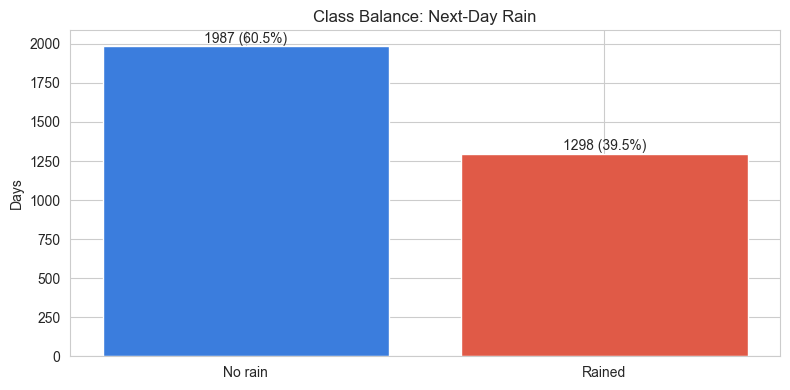

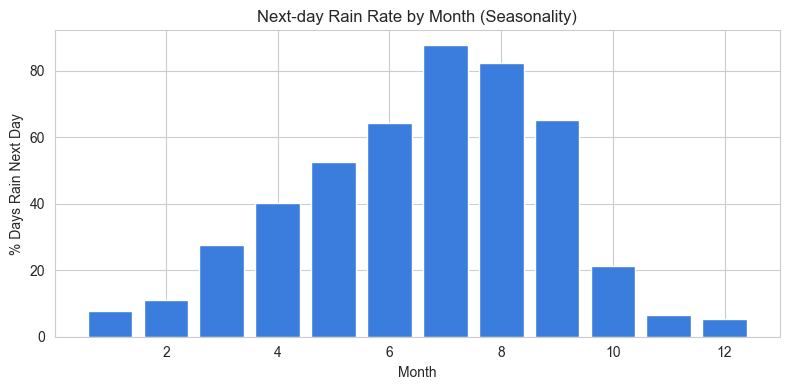

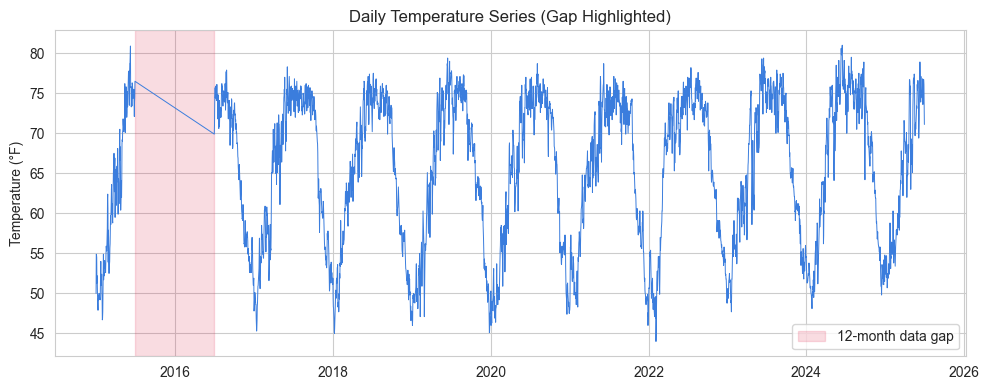

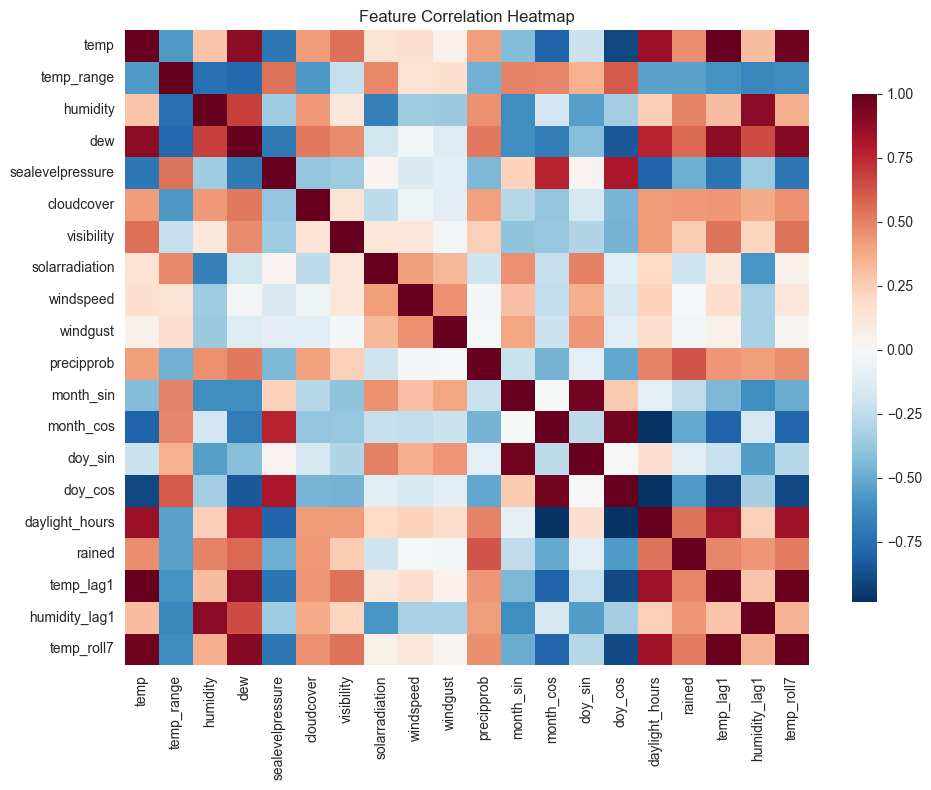

In [11]:
# 1. Class balance
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(["No rain", "Rained"], [(post["rain_next"] == 0).sum(), (post["rain_next"] == 1).sum()], color=["#3b7ddd", "#e05a47"])
for i, v in enumerate([(post["rain_next"] == 0).sum(), (post["rain_next"] == 1).sum()]):
    ax.text(i, v + 20, f"{v} ({v / len(post) * 100:.1f}%)", ha="center")
ax.set_title("Class Balance: Next-Day Rain")
ax.set_ylabel("Days")
plt.tight_layout()
plt.savefig(f"{OUT}/01_class_balance.png", dpi=130)
plt.show()

# 2. Monthly rain rate
post["ym"] = post["datetime"].dt.to_period("M").astype(str)
mr = post.groupby(post["datetime"].dt.month)["rain_next"].mean()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(mr.index, mr.values * 100, color="#3b7ddd")
ax.set_title("Next-day Rain Rate by Month (Seasonality)")
ax.set_xlabel("Month")
ax.set_ylabel("% Days Rain Next Day")
plt.tight_layout()
plt.savefig(f"{OUT}/02_monthly_rain.png", dpi=130)
plt.show()

# 3. Temperature time series & gap visualization
full = df.set_index("datetime")["temp"]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(full.index, full.values, lw=0.7, color="#3b7ddd")
ax.axvspan(pd.Timestamp("2015-07-01"), pd.Timestamp("2016-06-30"), color="crimson", alpha=0.15, label="12-month data gap")
ax.set_title("Daily Temperature Series (Gap Highlighted)")
ax.set_ylabel("Temperature (°F)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/03_temp_series_gap.png", dpi=130)
plt.show()

# 4. Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(post[FEATURES].corr(), cmap="RdBu_r", center=0, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{OUT}/04_correlation.png", dpi=130)
plt.show()

## 3. Chronological Dataset Splits & 14-Day Sliding Windows

- **Train Set**: 2016-07-01 to 2023-06-30
- **Validation Set**: 2023-07-01 to 2024-06-30
- **Test Set**: 2024-07-01 to 2025-06-30
- **StandardScaler**: Fitted ONLY on training set features to avoid data leakage
- **Windowing**: 14 consecutive days of features to predict day 15 label

In [12]:
def split(d0, d1):
    return post[(post["datetime"] >= d0) & (post["datetime"] <= d1)].reset_index(drop=True)

train_df = split("2016-07-01", "2023-06-30")
val_df = split("2023-07-01", "2024-06-30")
test_df = split("2024-07-01", "2025-06-30")
print("Splits record counts:", {k: len(v) for k, v in {"train": train_df, "val": val_df, "test": test_df}.items()})

scaler = StandardScaler().fit(train_df[FEATURES])

def scale(d):
    return scaler.transform(d[FEATURES]).astype(np.float32)

WINDOW = 14

def make_windows(darr, larr, dates, d0, d1):
    X, y = [], []
    for i in range(WINDOW, len(darr)):
        if (dates[i] - dates[i - WINDOW]).astype("timedelta64[D]").astype(int) != WINDOW:
            continue  # Avoid straddling calendar gaps
        td = dates[i]
        if not (pd.Timestamp(d0) <= td <= pd.Timestamp(d1)):
            continue
        X.append(darr[i - WINDOW:i])
        y.append(larr[i - WINDOW])
    return np.stack(X), np.array(y, dtype=np.int64)

full_arr = scale(post)
full_lab = post["rain_next"].values.astype(np.int64)
full_dates = post["datetime"].values.astype("datetime64[D]")

Xtr, ytr = make_windows(full_arr, full_lab, full_dates, "2016-07-01", "2023-06-30")
Xva, yva = make_windows(full_arr, full_lab, full_dates, "2023-07-01", "2024-06-30")
Xte, yte = make_windows(full_arr, full_lab, full_dates, "2024-07-01", "2025-06-30")
print("Window array shapes (X, y):")
print("  Train:", Xtr.shape)
print("  Val:  ", Xva.shape)
print("  Test: ", Xte.shape)

Splits record counts: {'train': 2555, 'val': 366, 'test': 364}
Window array shapes (X, y):
  Train: (2541, 14, 20)
  Val:   (366, 14, 20)
  Test:  (364, 14, 20)


## 4. Model Definition & Training Loop

We test 4 hyperparameter configurations:
1. **`A_baseline`**: 1-layer LSTM (hidden=64, dropout=0.2, lr=1e-3)
2. **`B_small`**: 1-layer LSTM (hidden=32, dropout=0.2, lr=1e-3)
3. **`C_deep_reg`**: 2-layer LSTM (hidden=64, dropout=0.5, lr=5e-4)
4. **`D_weighted`**: 1-layer LSTM with class-weighted CrossEntropyLoss

In [13]:
class LSTMClf(nn.Module):
    def __init__(self, n_feat, hidden=64, layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, layers, batch_first=True, dropout=dropout if layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, 2)
        
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(self.drop(h[-1]))

def evaluate(model, loader):
    model.eval()
    yp, yt, prob = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            yp += out.argmax(1).cpu().tolist()
            yt += yb.tolist()
            prob += out.softmax(1)[:, 1].cpu().tolist()
    acc = 100 * sum(a == b for a, b in zip(yp, yt)) / len(yt)
    return acc, yp, yt, np.array(prob)

CONFIGS = {
    "A_baseline": dict(hidden=64, layers=1, dropout=0.2, lr=1e-3, wd=1e-4, batch=64, epochs=15, cw=False),
    "B_small":    dict(hidden=32, layers=1, dropout=0.2, lr=1e-3, wd=1e-4, batch=64, epochs=15, cw=False),
    "C_deep_reg": dict(hidden=64, layers=2, dropout=0.5, lr=5e-4, wd=1e-4, batch=64, epochs=15, cw=False),
    "D_weighted": dict(hidden=64, layers=1, dropout=0.2, lr=1e-3, wd=1e-4, batch=64, epochs=15, cw=True),
}

histories, results = {}, {}
n_neg, n_pos = (ytr == 0).sum(), (ytr == 1).sum()
w = torch.tensor([1.0, n_neg / n_pos], dtype=torch.float32).to(device)

for name, c in CONFIGS.items():
    print(f"\n{'='*20} {name} {'='*20}")
    print("Configuration:", c)
    tr_l = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)), batch_size=c["batch"], shuffle=True)
    va_l = DataLoader(TensorDataset(torch.from_numpy(Xva), torch.from_numpy(yva)), batch_size=c["batch"])
    te_l = DataLoader(TensorDataset(torch.from_numpy(Xte), torch.from_numpy(yte)), batch_size=c["batch"])
    
    model = LSTMClf(Xtr.shape[2], c["hidden"], c["layers"], c["dropout"]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=c["lr"], weight_decay=c["wd"])
    loss_fn = nn.CrossEntropyLoss(weight=w if c["cw"] else None)
    
    hist = {"loss": [], "val_loss": [], "acc": [], "val_acc": []}
    best, bad, best_state = 1e9, 0, None
    
    for epoch in range(c["epochs"]):
        model.train()
        tl = 0
        for xb, yb in tr_l:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            tl += loss.item() * len(xb)
            
        model.eval()
        vl = 0
        with torch.no_grad():
            for xb, yb in va_l:
                xb, yb = xb.to(device), yb.to(device)
                vl += loss_fn(model(xb), yb).item() * len(xb)
                
        tracc, _, _, _ = evaluate(model, tr_l)
        vaacc, _, _, _ = evaluate(model, va_l)
        hist["loss"].append(tl / len(tr_l.dataset))
        hist["val_loss"].append(vl / len(va_l.dataset))
        hist["acc"].append(tracc)
        hist["val_acc"].append(vaacc)
        
        print(f"ep{epoch+1:02d}: loss {hist['loss'][-1]:.4f} | val_loss {hist['val_loss'][-1]:.4f} | train_acc {tracc:.1f}% | val_acc {vaacc:.1f}%")
        
        if hist["val_loss"][-1] < best - 1e-4:
            best, bad, best_state = hist["val_loss"][-1], 0, {k: v.cpu() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= 3:
                print("Early stopping triggered")
                break
                
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    teacc, yp, yt, pr = evaluate(model, te_l)
    rep = classification_report(yt, yp, target_names=["No rain", "Rained"], output_dict=True, zero_division=0)
    print("\nTest Classification Report:")
    print(classification_report(yt, yp, target_names=["No rain", "Rained"], zero_division=0))
    
    torch.save(model.state_dict(), f"{OUT}/{name}.pt")
    histories[name] = hist
    results[name] = {
        "test_acc": teacc, "report": rep, "y_pred": yp, "y_true": yt,
        "y_prob": pr.tolist(), "n_epochs": len(hist["loss"]), "config": c
    }


==================== A_baseline ====================
Configuration: {'hidden': 64, 'layers': 1, 'dropout': 0.2, 'lr': 0.001, 'wd': 0.0001, 'batch': 64, 'epochs': 15, 'cw': False}
ep01: loss 0.5260 | val_loss 0.5439 | train_acc 78.0% | val_acc 74.6%
ep02: loss 0.4611 | val_loss 0.5152 | train_acc 78.0% | val_acc 76.8%
ep03: loss 0.4487 | val_loss 0.4948 | train_acc 81.0% | val_acc 78.7%
ep04: loss 0.4147 | val_loss 0.4610 | train_acc 82.9% | val_acc 80.9%
ep05: loss 0.3861 | val_loss 0.4548 | train_acc 84.8% | val_acc 82.0%
ep06: loss 0.3711 | val_loss 0.3898 | train_acc 85.7% | val_acc 83.1%
ep07: loss 0.3413 | val_loss 0.3491 | train_acc 85.7% | val_acc 83.3%
ep08: loss 0.3224 | val_loss 0.3167 | train_acc 86.7% | val_acc 85.8%
ep09: loss 0.3083 | val_loss 0.3162 | train_acc 87.4% | val_acc 84.4%
ep10: loss 0.2908 | val_loss 0.3165 | train_acc 86.7% | val_acc 84.4%
ep11: loss 0.2860 | val_loss 0.3471 | train_acc 85.2% | val_acc 83.9%
ep12: loss 0.2852 | val_loss 0.3138 | train_acc 86

## 5. Comparative Evaluation & Visualization Plots

Plots created:
1. **Training & Validation Curves** (Loss and Accuracy)
2. **Precision, Recall, F1-Score & Accuracy Comparison**
3. **Confusion Matrices** for top models
4. **ROC Curves & AUC Scores**

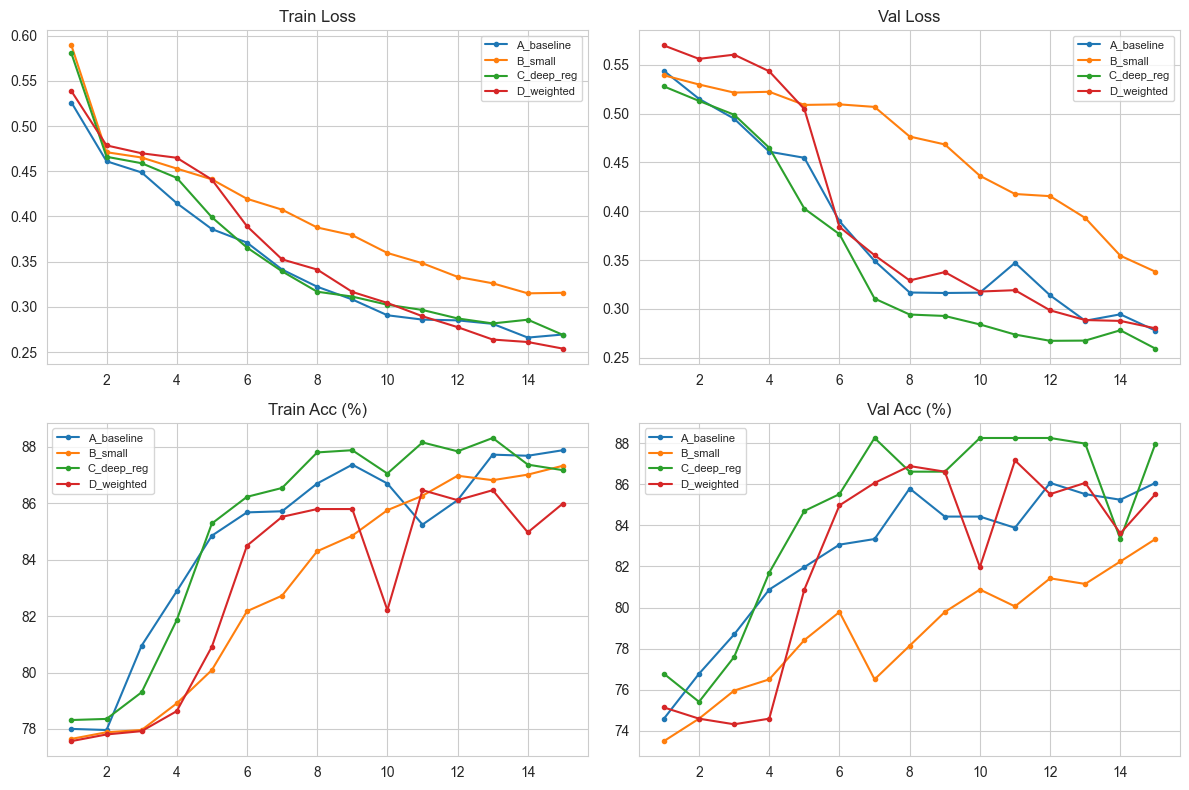

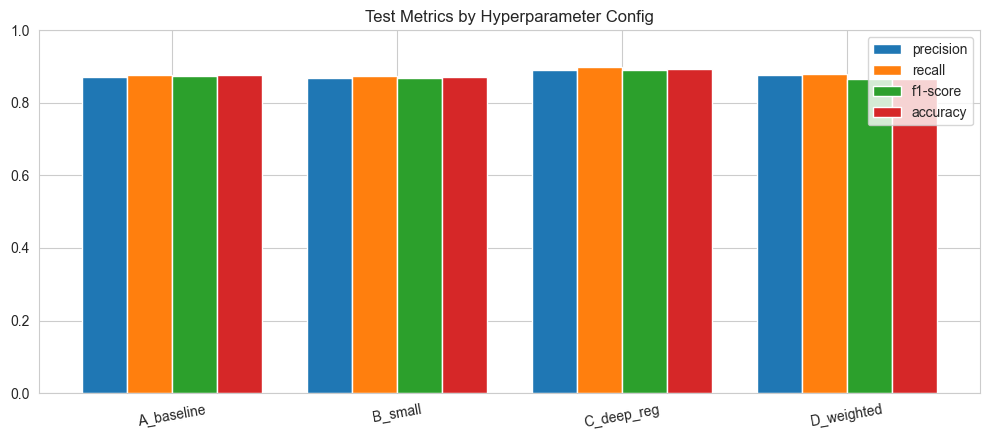

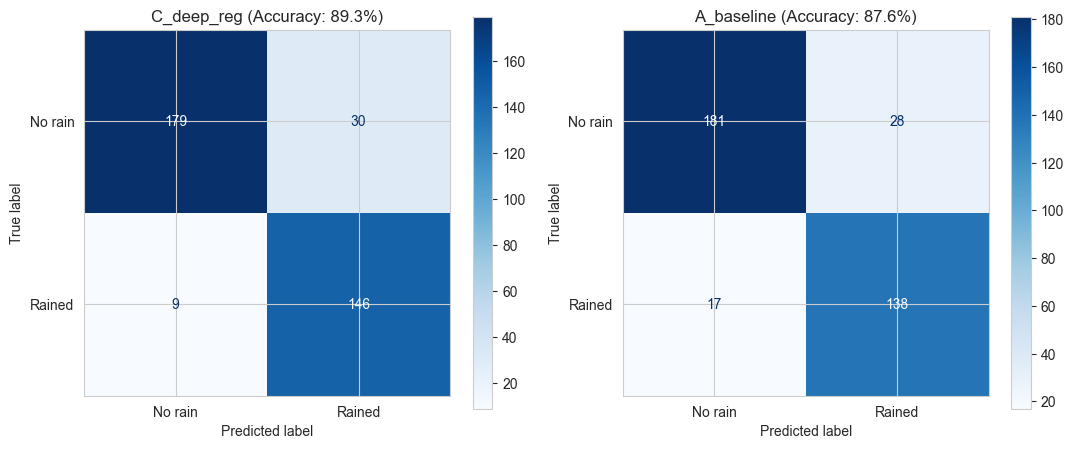

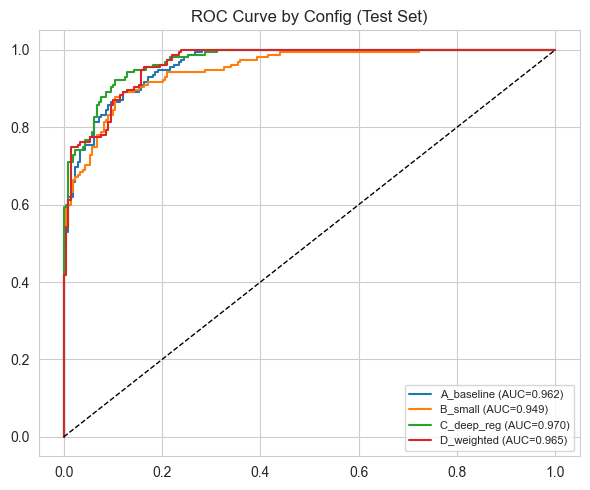

In [14]:
# 1. Training Curves
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, key, ttl in zip(axes.flat, ["loss", "val_loss", "acc", "val_acc"], ["Train Loss", "Val Loss", "Train Acc (%)", "Val Acc (%)"]):
    for n, h in histories.items():
        ax.plot(range(1, len(h[key]) + 1), h[key], marker="o", ms=3, label=n)
    ax.set_title(ttl)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT}/05_training_curves.png", dpi=130)
plt.show()

# 2. Performance Comparison Bar Chart
names = list(results)
x = np.arange(len(names))
wbar = 0.2
mets = {m: [results[n]["report"]["macro avg"][m] for n in names] for m in ["precision", "recall", "f1-score"]}
accs = [results[n]["test_acc"] / 100 for n in names]

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, (m, v) in enumerate({**mets, "accuracy": accs}.items()):
    ax.bar(x + i * wbar, v, wbar, label=m)
ax.set_xticks(x + wbar * 1.5)
ax.set_xticklabels(names, rotation=10)
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("Test Metrics by Hyperparameter Config")
plt.tight_layout()
plt.savefig(f"{OUT}/06_metrics_bars.png", dpi=130)
plt.show()

# 3. Confusion Matrices of Top 2 Models
best2 = sorted(names, key=lambda n: results[n]["report"]["macro avg"]["f1-score"], reverse=True)[:2]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, n in zip(axes, best2):
    ConfusionMatrixDisplay.from_predictions(
        results[n]["y_true"], results[n]["y_pred"],
        display_labels=["No rain", "Rained"], cmap="Blues", ax=ax
    )
    ax.set_title(f"{n} (Accuracy: {results[n]['test_acc']:.1f}%)")
plt.tight_layout()
plt.savefig(f"{OUT}/07_confusion_matrices.png", dpi=130)
plt.show()

# 4. ROC Curves
fig, ax = plt.subplots(figsize=(6, 5))
for n in names:
    fpr, tpr, _ = roc_curve(results[n]["y_true"], results[n]["y_prob"])
    ax.plot(fpr, tpr, label=f"{n} (AUC={auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.legend(fontsize=8)
ax.set_title("ROC Curve by Config (Test Set)")
plt.tight_layout()
plt.savefig(f"{OUT}/08_roc.png", dpi=130)
plt.show()